In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import collections

In [2]:
def extract_all_bank_questions(json_file):
    all_questions = []
    
    with open(json_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                doc = json.loads(line)
                for section in doc.get('questions', []):
                    section_questions = section.get('questions', [])
                    for q_item in section_questions:
                        if isinstance(q_item, dict):
                            text = q_item.get('question')
                        else:
                            text = q_item
                        
                        if text:
                            all_questions.append(text)
            except json.JSONDecodeError as e:
                print(f"Skipping malformed JSON at line {line_num}: {e}")
                
    return pd.DataFrame({'text': all_questions, 'source': 'Question Bank'})

def classify_bloom(text):
    text = str(text).lower()
    taxonomy = {
        "Analyze/Evaluate": [
            "why", "compare", "contrast", "significance", "role of", "convey", "how does", 
            "analyze", "examine", "breakdown", "categorize", "differentiate", "discriminate", 
            "point out", "survey", "test", "appraise", "judge", "critique", "defend", 
            "justify", "recommend", "support", "conclude", "determine", "explain why", 
            "investigate", "debate", "prioritize", "verify", "assess"
        ],
        "Apply": [
            "solve", "show", "calculate", "illustrate", "use", "complete", "construct", 
            "employ", "practice", "operate", "schedule", "sketch", "apply", "choose", 
            "dramatize", "execute", "implement", "prepare", "produce", "relate", 
            "compute", "change", "discover", "modify", "show how", "solve for", 
            "manipulate", "transfer", "predict"
        ],
        "Understand": [
            "explain", "describe", "identify", "main idea", "summarize", "theme", 
            "interpret", "discuss", "paraphrase", "translate", "classify", "restate", 
            "rewrite", "report", "give examples", "distinguish", "generalize", 
            "express", "outline", "recognize", "review", "observe", "indicate", 
            "clarify", "infer", "meaning", "relationship", "characterize", "justify", 
            "compare", "contrast", "exemplify"
        ],
        "Remember": [
            "what is", "list", "who", "when", "how many", "name", "true or false", 
            "define", "state", "label", "recall", "match", "select", "find", 
            "tell", "recite", "locate", "write", "mention", "point out", "pick", 
            "record", "repeat", "specify", "reproduce", "list the", "where is", 
            "which one", "memorize", "which of"
        ]
    }
    
    for level, keywords in taxonomy.items():
        if any(word in text for word in keywords):
            return level
    return "Other"

def get_top_starters(df):
        others_series = df[df['bloom_taxon'] == "Other"]['text'].dropna().astype(str)
        others = others_series.tolist()
        
        starters = []
        for q in others:
            words = q.lower().split()
            if len(words) >= 2:
                starters.append(" ".join(words[:2]))
        return collections.Counter(starters).most_common(20)

In [ ]:
lba_base_path = '' # Path to the combined LBA questions file
sc_question_bank_path = ''

In [ ]:
bank_df = extract_all_bank_questions(sc_question_bank_path)
combined_df = pd.read_csv(lba_base_path)

In [6]:
combined_df['bloom_taxon'] = combined_df['text'].apply(classify_bloom)
bank_df['bloom_taxon'] = bank_df['text'].apply(classify_bloom)

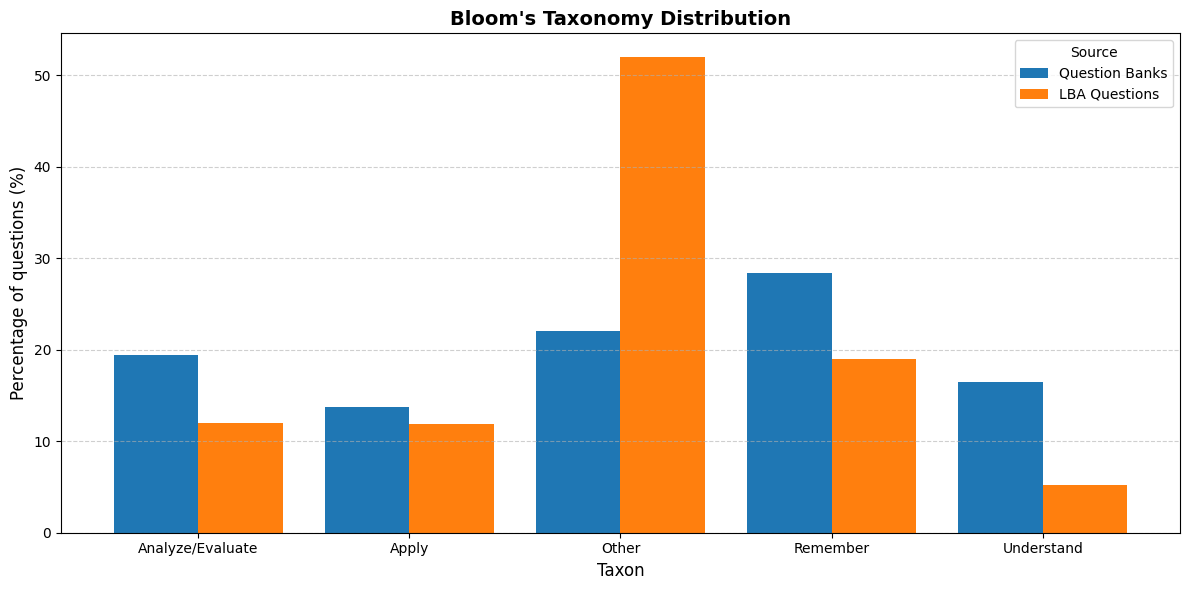

In [7]:
comparison = pd.DataFrame({ "Question Banks": bank_df['bloom_taxon'].value_counts(normalize=True), "LBA Questions": combined_df['bloom_taxon'].value_counts(normalize=True)}).fillna(0) * 100

ax = comparison.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'], width=0.8)

plt.title("Bloom's Taxonomy Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of questions (%)", fontsize=12)
plt.xlabel("Taxon", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

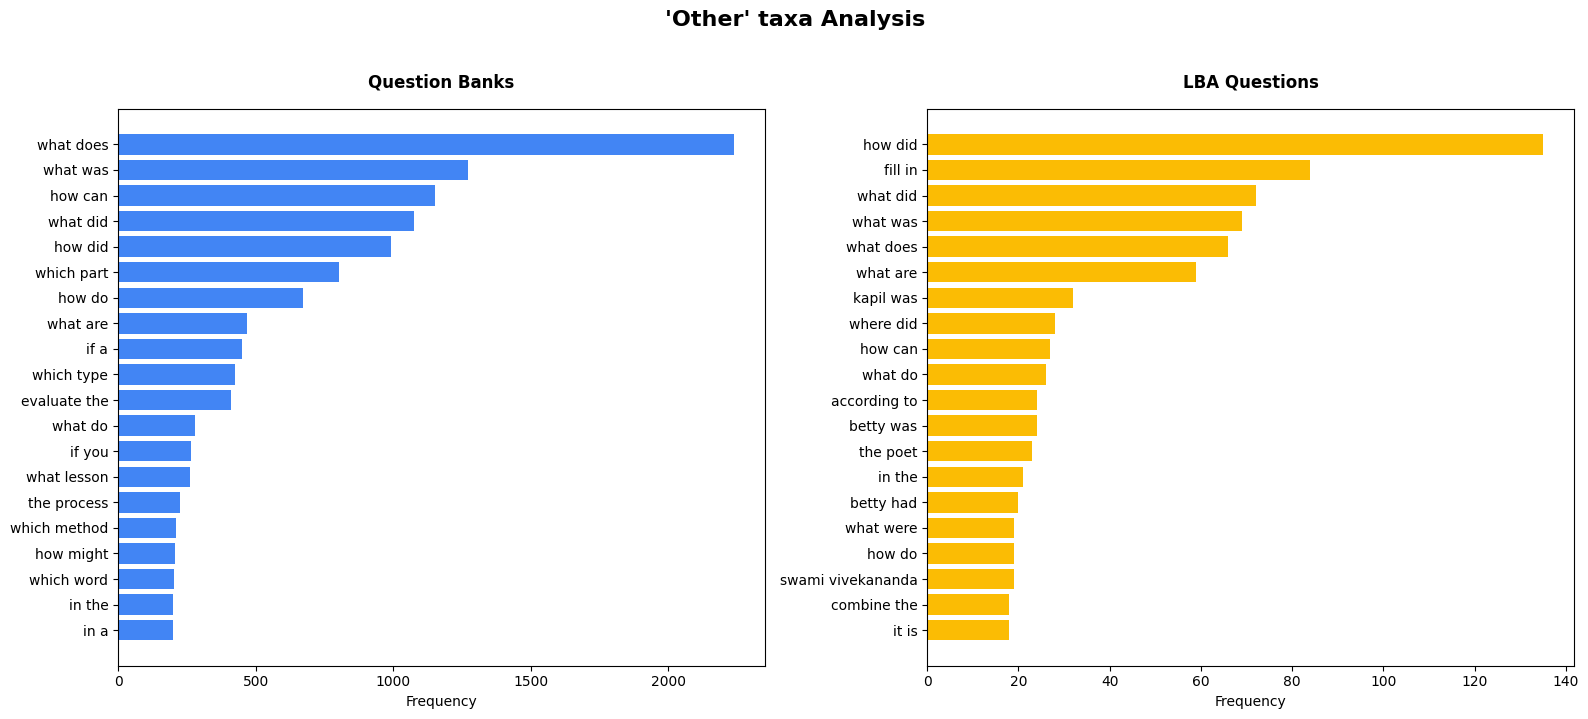

In [8]:
bank_starters = get_top_starters(bank_df)
lba_starters = get_top_starters(combined_df)
df_bank = pd.DataFrame(bank_starters, columns=['Phrase', 'Count'])
df_lba = pd.DataFrame(lba_starters, columns=['Phrase', 'Count'])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(df_bank['Phrase'], df_bank['Count'], color='#4285F4')
ax1.set_title("Question Banks", fontweight='bold', pad=15)
ax1.invert_yaxis() 
ax1.set_xlabel("Frequency")


ax2.barh(df_lba['Phrase'], df_lba['Count'], color='#FBBC04')
ax2.set_title("LBA Questions", fontweight='bold', pad=15)
ax2.invert_yaxis()
ax2.set_xlabel("Frequency")

plt.suptitle("'Other' taxa Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
